# Classification Task: Predicting Burnout

## Problem Definition

The purpose of this classification task is to predict whether an individual presents signs of burnout based on demographic, lifestyle, digital behavior, and mental health-related variables.

The target variable is `Burnout`, which contains two classes:

- 0: No Burnout
- 1: Burnout

The input variables include age, gender, occupation, daily screen time, social media usage, night usage, sleep duration, work/study hours, physical activity, social interaction score, caffeine intake, smoking, alcohol consumption, depression, anxiety, and stress level.

This problem is relevant because burnout can be associated with lifestyle habits, stress, sleep patterns, social interaction, and digital behavior. A machine learning model can help identify patterns related to burnout risk in the dataset.

The dataset is synthetic and is used for educational and machine learning practice. Therefore, the results should be interpreted as a data science exercise, not as a clinical or psychological diagnosis.

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

In [30]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "mental_health.csv"

df = pd.read_csv(DATA_PATH)

df.head()



,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [36]:
print("Dataset shape:", df.shape)


Dataset shape: (2000, 18)


In [34]:
print(df.columns.tolist())

['Person_ID', 'Age', 'Gender', 'Occupation', 'Daily_Screen_Time', 'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours', 'Physical_Activity', 'Social_Interaction_Score', 'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety', 'Burnout']


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   Occupation                2000 non-null   object 
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   object 
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol 

In [32]:
df.isnull().sum()

Person_ID                   0
Age                         0
Gender                      0
Occupation                  0
Daily_Screen_Time           0
Social_Media_Usage          0
Night_Usage                 0
Sleep_Hours                 0
Stress_Level                0
Work_Study_Hours            0
Physical_Activity           0
Social_Interaction_Score    0
Caffeine_Intake             0
Smoking                     0
Alcohol                     0
Depression                  0
Anxiety                     0
Burnout                     0
dtype: int64

In [33]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,577.494589,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,1.000000,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,1500.250000,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2000.000000,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Initial Dataset Inspection

The dataset contains 2,000 records and 18 columns. It includes both numerical and categorical variables related to demographics, lifestyle habits, digital behavior, and mental health indicators.

The numerical variables include age, daily screen time, social media usage, sleep hours, stress level, work/study hours, physical activity, social interaction score, caffeine intake, depression, anxiety, and burnout-related indicators.

No missing values were identified in the dataset, so no imputation is required at this stage.

The dataset is suitable for supervised machine learning because it contains several potential input features and target variables that can be used for both classification and regression tasks.

In [38]:
df.dtypes

Person_ID                     int64
Age                           int64
Gender                       object
Occupation                   object
Daily_Screen_Time           float64
Social_Media_Usage          float64
Night_Usage                   int64
Sleep_Hours                 float64
Stress_Level                  int64
Work_Study_Hours            float64
Physical_Activity            object
Social_Interaction_Score      int64
Caffeine_Intake               int64
Smoking                       int64
Alcohol                       int64
Depression                    int64
Anxiety                       int64
Burnout                       int64
dtype: object

In [39]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Gender', 'Occupation', 'Physical_Activity']


In [40]:
for col in categorical_columns:
    print("\n" + col)
    print(df[col].value_counts())


Gender
Gender
Female    1008
Male       992
Name: count, dtype: int64

Occupation
Occupation
Student       677
Unemployed    677
Employed      646
Name: count, dtype: int64

Physical_Activity
Physical_Activity
Low       682
Medium    662
High      656
Name: count, dtype: int64


In [41]:
df["Burnout"].value_counts()

Burnout
1    1031
0     969
Name: count, dtype: int64

In [42]:
df["Burnout"].value_counts(normalize=True) * 100

Burnout
1    51.55
0    48.45
Name: proportion, dtype: float64

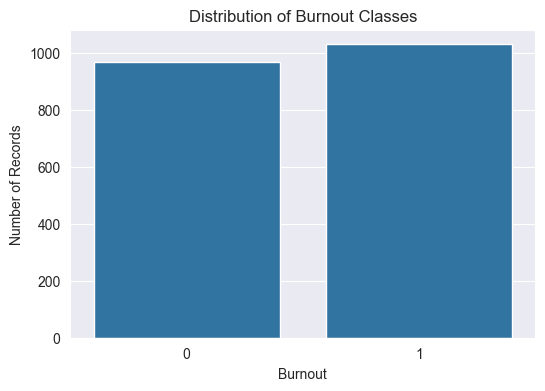

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Burnout")
plt.title("Distribution of Burnout Classes")
plt.xlabel("Burnout")
plt.ylabel("Number of Records")
plt.show()

## Target Variable Distribution

The target variable for the classification task is `Burnout`.

The distribution is almost balanced:
- Class 1 represents individuals with burnout signs.
- Class 0 represents individuals without burnout signs.

Since the two classes are close in size, the classification task is not strongly affected by class imbalance. Therefore, metrics such as accuracy, precision, recall, F1-score, and ROC-AUC can be interpreted more reliably.

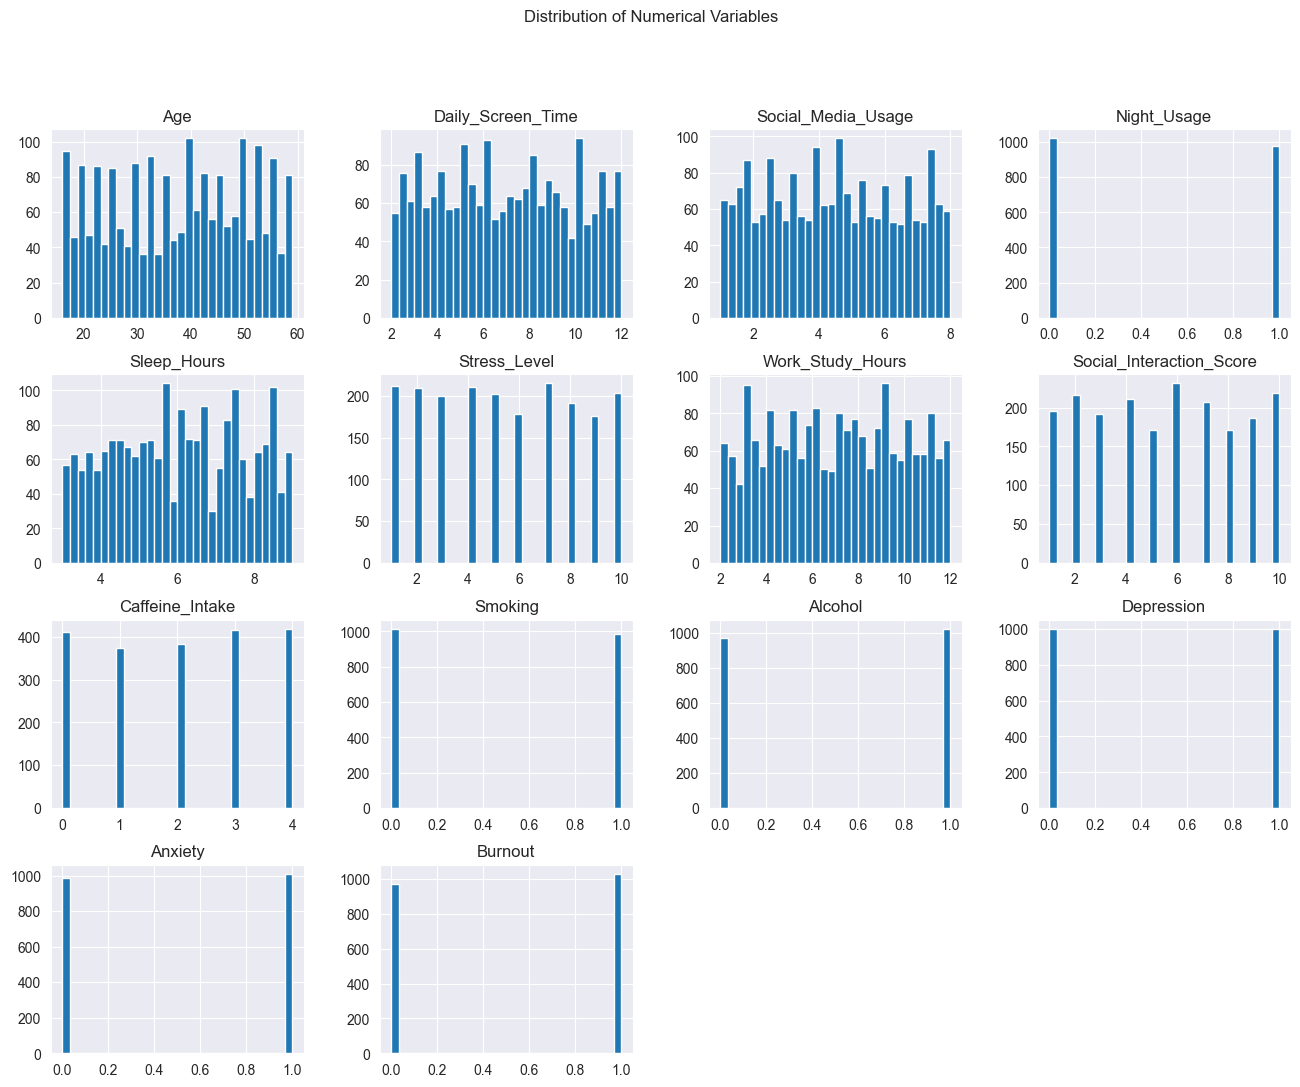

In [44]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_columns.remove("Person_ID")

df[numeric_columns].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Variables")
plt.show()

## Numerical Variables Distribution

The histograms show the distribution of the numerical variables in the dataset. Variables such as age, daily screen time, social media usage, sleep hours, work/study hours, stress level, social interaction score, caffeine intake, depression, anxiety, and burnout are represented numerically.

Some variables are continuous, while others are discrete or binary. For example, `Night_Usage`, `Smoking`, `Alcohol`, `Depression`, `Anxiety`, and `Burnout` contain binary values. The target variable `Burnout` is almost balanced, which is useful for the classification task.

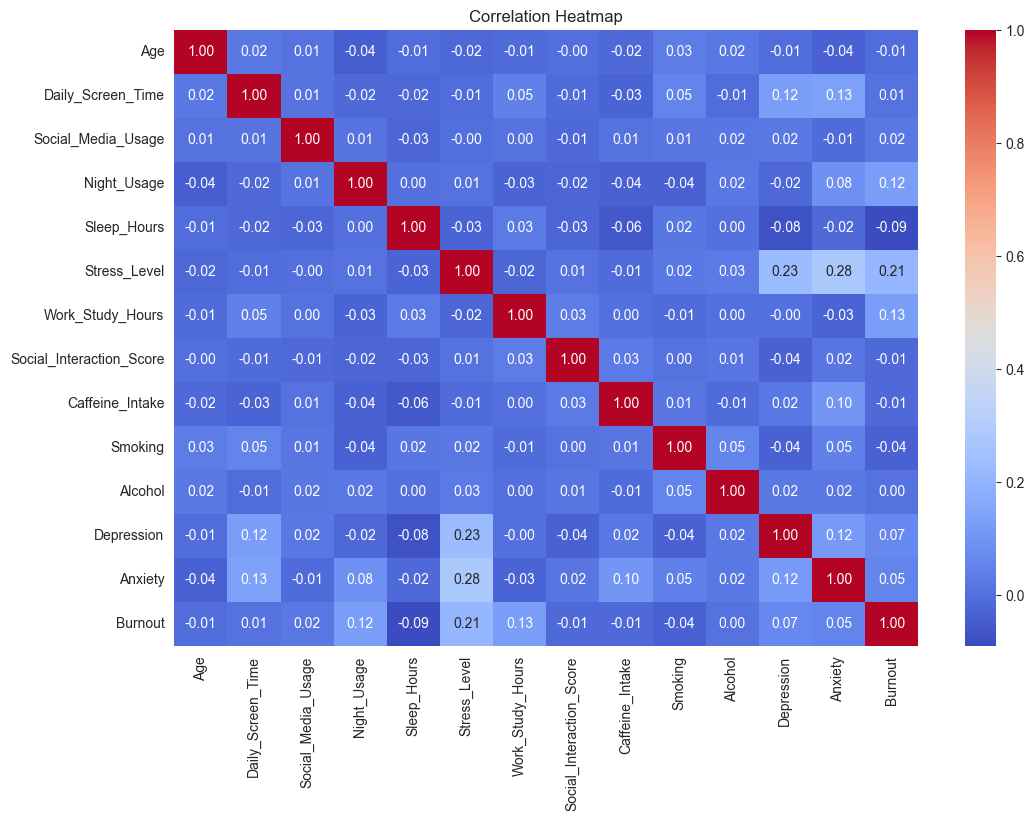

In [45]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

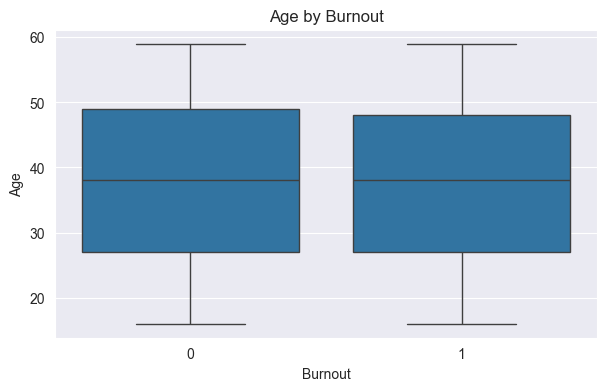

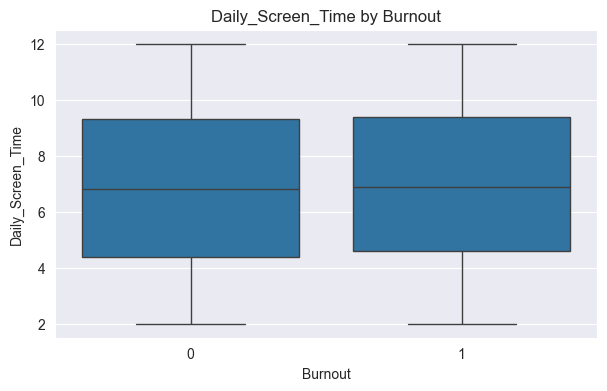

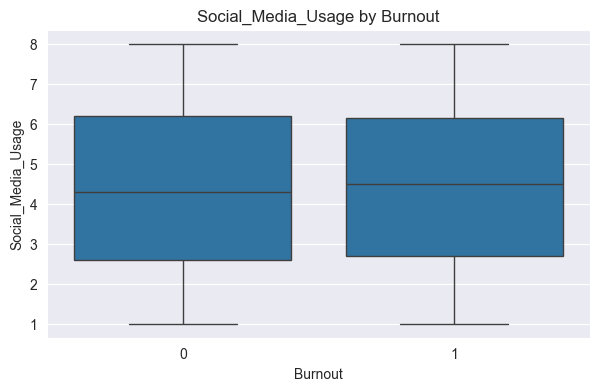

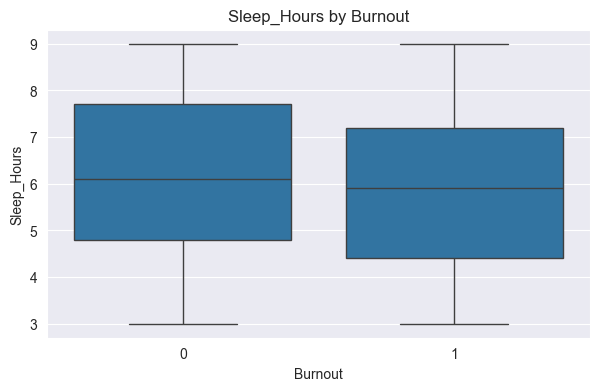

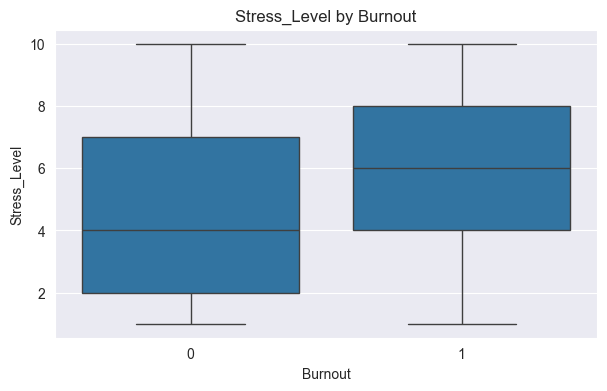

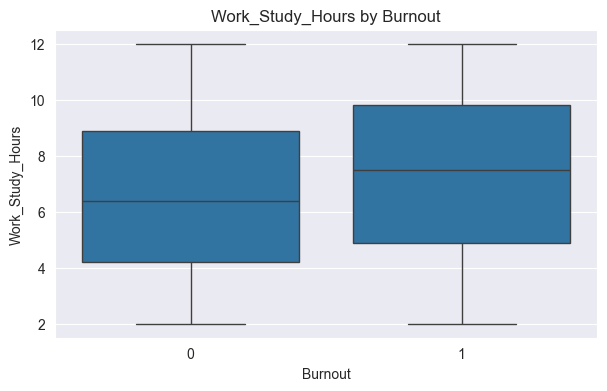

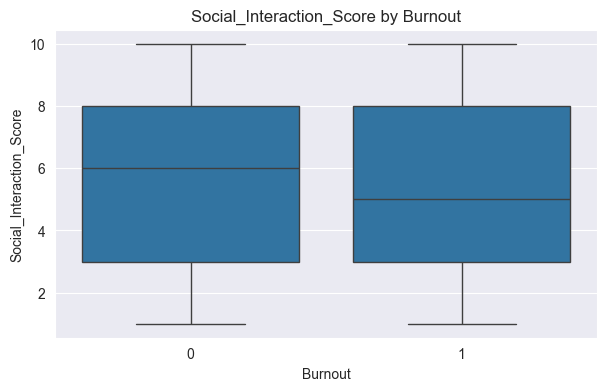

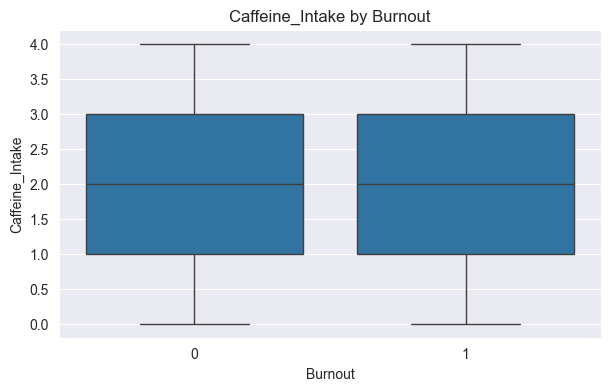

In [46]:
important_numeric_features = [
    "Age",
    "Daily_Screen_Time",
    "Social_Media_Usage",
    "Sleep_Hours",
    "Stress_Level",
    "Work_Study_Hours",
    "Social_Interaction_Score",
    "Caffeine_Intake"
]

for col in important_numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Burnout", y=col)
    plt.title(f"{col} by Burnout")
    plt.xlabel("Burnout")
    plt.ylabel(col)
    plt.show()

In [47]:
X = df.drop(columns=["Person_ID", "Burnout"])
y = df["Burnout"]

X.head()

,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety
0,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1
1,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0
2,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0
3,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0
4,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1500, 16)
Test shape: (500, 16)


In [49]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Daily_Screen_Time', 'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours', 'Social_Interaction_Score', 'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety']
Categorical features: ['Gender', 'Occupation', 'Physical_Activity']


In [51]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

In [52]:
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Explainable Boosting Machine": ExplainableBoostingClassifier(random_state=42)
}

In [53]:
results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    })

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

Training Naive Bayes...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Support Vector Machine...
Training K-Nearest Neighbors...
Training XGBoost...
Training CatBoost...
Training Explainable Boosting Machine...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression,0.618,0.635628,0.608527,0.621782,0.659091
8,Explainable Boosting Machine,0.618,0.636735,0.604651,0.620278,0.661477
6,XGBoost,0.598,0.605948,0.631783,0.618596,0.632680
4,Support Vector Machine,0.614,0.632653,0.600775,0.616302,0.672569
0,Naive Bayes,0.608,0.630252,0.581395,0.604839,0.646342
7,CatBoost,0.602,0.620408,0.589147,0.604374,0.650682
3,Random Forest,0.600,0.623932,0.565891,0.593496,0.640312
5,K-Nearest Neighbors,0.544,0.556391,0.573643,0.564885,0.554824
2,Decision Tree,0.558,0.578059,0.531008,0.553535,0.558892


In [54]:
top_5_models = results_df.head(5)
top_5_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression,0.618,0.635628,0.608527,0.621782,0.659091
8,Explainable Boosting Machine,0.618,0.636735,0.604651,0.620278,0.661477
6,XGBoost,0.598,0.605948,0.631783,0.618596,0.632680
4,Support Vector Machine,0.614,0.632653,0.600775,0.616302,0.672569
0,Naive Bayes,0.608,0.630252,0.581395,0.604839,0.646342


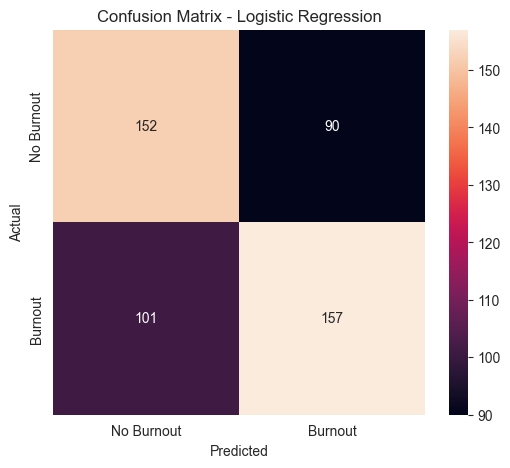

In [57]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
print("Best model:", best_model_name)
print()

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["No Burnout", "Burnout"]
    )
)

Best model: Logistic Regression

              precision    recall  f1-score   support

  No Burnout       0.60      0.63      0.61       242
     Burnout       0.64      0.61      0.62       258

    accuracy                           0.62       500
   macro avg       0.62      0.62      0.62       500
weighted avg       0.62      0.62      0.62       500



## Classification Report Interpretation

The classification report confirms that Logistic Regression is the best baseline model for the burnout classification task.

The model achieved an accuracy of 0.62 and a weighted F1-score of 0.62. Since the target variable is almost balanced, these results suggest that the model performs better than a random baseline.

For the `No Burnout` class, the recall is 0.63, meaning that the model correctly identifies 63% of the individuals without burnout. For the `Burnout` class, the recall is 0.61, meaning that the model correctly identifies 61% of the individuals with burnout.

The precision values are also relatively balanced between the two classes. Overall, the results indicate that burnout can be predicted to some extent using the available demographic, lifestyle, digital behavior, and mental health-related features.

In [59]:
OUTPUT_METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "classification_base_models_results.csv"

results_df.to_csv(OUTPUT_METRICS_PATH, index=False)

print("Saved to:", OUTPUT_METRICS_PATH)

Saved to: D:\faculta\an3\sem2\ProiectMl\outputs\metrics\classification_base_models_results.csv


## Hyperparameter Tuning for the Top 5 Classification Models

After training and comparing the baseline classification models, the five best-performing models were selected for hyperparameter tuning.

The selected models are:

1. Logistic Regression
2. Explainable Boosting Machine
3. XGBoost
4. Support Vector Machine
5. Naive Bayes

The goal of this step is to identify better hyperparameter combinations and evaluate whether the tuned models improve over the baseline models.

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
tuning_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Explainable Boosting Machine": ExplainableBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [62]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["liblinear", "lbfgs"],
        "model__class_weight": [None, "balanced"]
    },

    "Explainable Boosting Machine": {
        "model__learning_rate": [0.01, 0.05],
        "model__max_bins": [64, 128],
        "model__interactions": [0, 5]
    },

    "XGBoost": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [2, 3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    },

    "Support Vector Machine": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "Naive Bayes": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    }
}

In [63]:
tuned_results = []
tuned_models = {}

for model_name, model in tuning_models.items():
    print(f"Tuning {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="f1",
        cv=3,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_pipeline = grid_search.best_estimator_
    y_pred = best_pipeline.predict(X_test)

    if hasattr(best_pipeline.named_steps["model"], "predict_proba"):
        y_proba = best_pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    tuned_results.append({
        "Model": model_name,
        "Best Parameters": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    })

    tuned_models[model_name] = best_pipeline

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by="F1 Score", ascending=False)

tuned_results_df

Tuning Logistic Regression...
Tuning Explainable Boosting Machine...
Tuning XGBoost...
Tuning Support Vector Machine...
Tuning Naive Bayes...


,Model,Best Parameters,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Explainable Boosting Machine,"{'model__interactions': 0, 'model__learning_ra...",0.626,0.642570,0.620155,0.631164,0.654766
3,Support Vector Machine,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.614,0.622642,0.639535,0.630975,0.669550
0,Logistic Regression,"{'model__C': 0.01, 'model__class_weight': None...",0.624,0.640000,0.620155,0.629921,0.664713
4,Naive Bayes,{'model__var_smoothing': 1e-09},0.608,0.630252,0.581395,0.604839,0.646342
2,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",0.604,0.625000,0.581395,0.602410,0.656048


In [64]:
TUNED_METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "classification_tuned_models_results.csv"

tuned_results_df.to_csv(TUNED_METRICS_PATH, index=False)

print("Saved to:", TUNED_METRICS_PATH)

Saved to: D:\faculta\an3\sem2\ProiectMl\outputs\metrics\classification_tuned_models_results.csv


In [65]:
best_tuned_model_name = tuned_results_df.iloc[0]["Model"]
best_tuned_model = tuned_models[best_tuned_model_name]

print("Best tuned model:", best_tuned_model_name)
print("Best parameters:")
print(tuned_results_df.iloc[0]["Best Parameters"])

Best tuned model: Explainable Boosting Machine
Best parameters:
{'model__interactions': 0, 'model__learning_rate': 0.01, 'model__max_bins': 64}


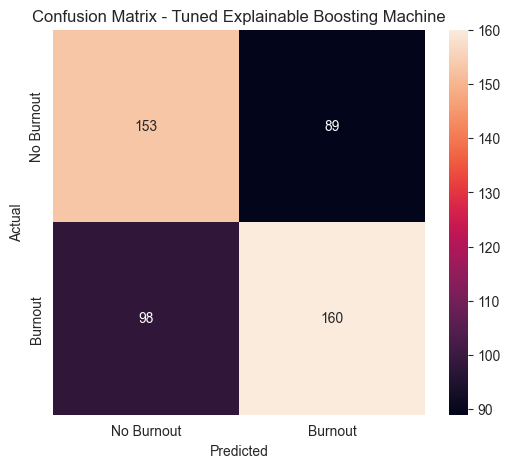

In [66]:
y_pred_tuned = best_tuned_model.predict(X_test)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    xticklabels=["No Burnout", "Burnout"],
    yticklabels=["No Burnout", "Burnout"]
)

plt.title(f"Confusion Matrix - Tuned {best_tuned_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
print("Best tuned model:", best_tuned_model_name)
print()

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["No Burnout", "Burnout"]
    )
)

Best tuned model: Explainable Boosting Machine

              precision    recall  f1-score   support

  No Burnout       0.61      0.63      0.62       242
     Burnout       0.64      0.62      0.63       258

    accuracy                           0.63       500
   macro avg       0.63      0.63      0.63       500
weighted avg       0.63      0.63      0.63       500



## Hyperparameter Tuning Interpretation

The hyperparameter tuning step was applied to the top five baseline classification models using GridSearchCV.

After tuning, the best-performing model was the Explainable Boosting Machine. It achieved an accuracy of approximately 0.626 and an F1-score of approximately 0.631.

The best hyperparameters were:
- interactions: 0
- learning_rate: 0.01
- max_bins: 64

Compared to the best baseline model, Logistic Regression, the tuned Explainable Boosting Machine produced a small improvement in F1-score. This shows that hyperparameter tuning improved the classification performance, although the improvement was limited.

The results suggest that burnout can be predicted to some extent from the available variables, but the moderate performance indicates that the classes are not perfectly separable.

## Learning Curves for the Top 5 Tuned Classification Models

Learning curves are used to analyze how model performance changes as the size of the training set increases.

They help identify possible overfitting or underfitting by comparing the training score with the validation score.

In [68]:
from sklearn.model_selection import learning_curve

Learning curve for Explainable Boosting Machine...


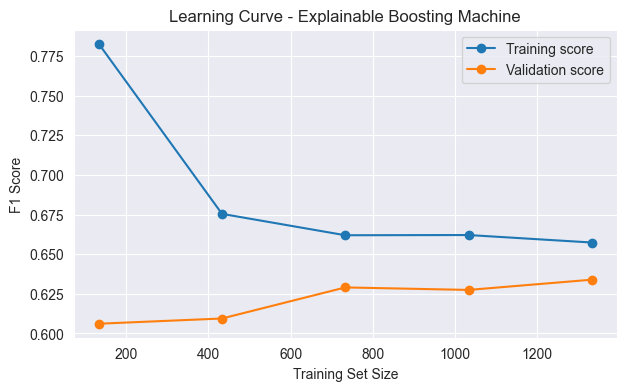

Learning curve for Support Vector Machine...


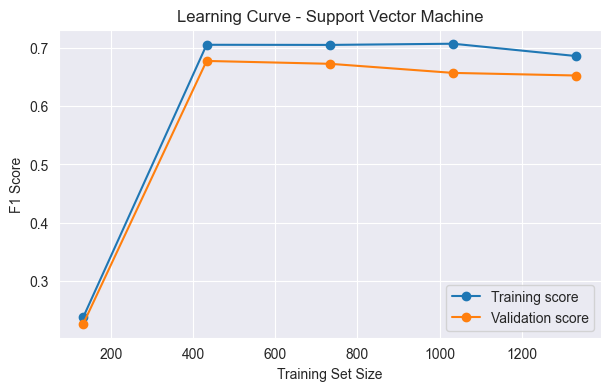

Learning curve for Logistic Regression...


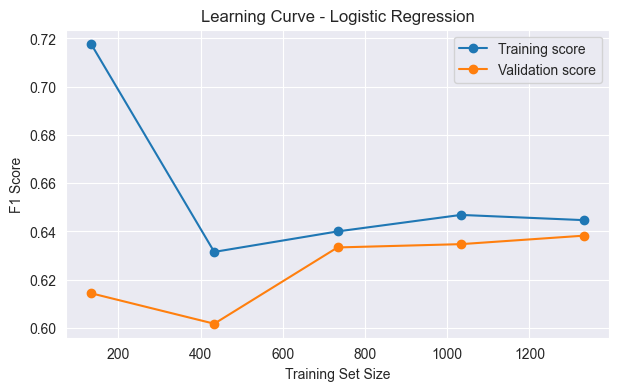

Learning curve for Naive Bayes...


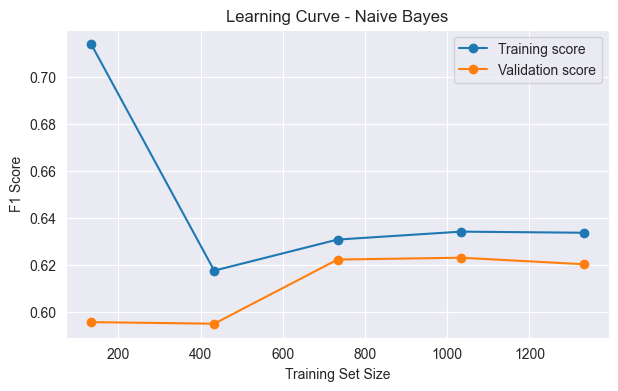

Learning curve for XGBoost...


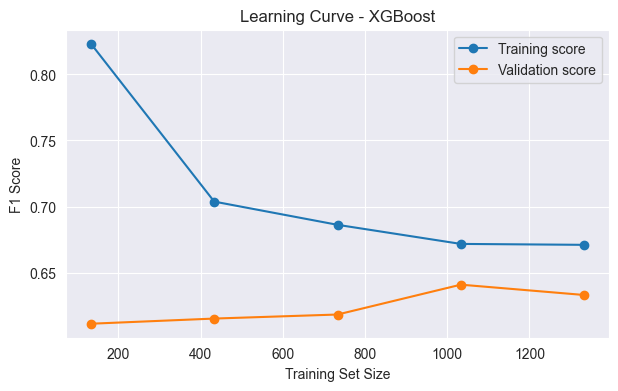

In [69]:
top_5_tuned_model_names = tuned_results_df["Model"].head(5).tolist()

for model_name in top_5_tuned_model_names:
    print(f"Learning curve for {model_name}...")

    model = tuned_models[model_name]

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validation score")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

## Learning Curves Interpretation

The learning curves show how the training and validation F1-scores change as the training set size increases.

For Logistic Regression, Support Vector Machine, Naive Bayes, and Explainable Boosting Machine, the training and validation curves become relatively close when more training data is used. This suggests that these models generalize reasonably well and do not show severe overfitting.

For XGBoost, the training score remains higher than the validation score, especially for smaller training set sizes. This indicates a mild tendency toward overfitting, although the validation score improves as more training data is used.

Overall, the learning curves confirm that the models achieve moderate predictive performance. The gap between training and validation scores is not extremely large for most models, which suggests that the main limitation is not severe overfitting, but rather the moderate predictive signal available in the dataset.

## SHAP Explainability Analysis for the Top 3 Tuned Models

SHAP is used to interpret how each feature contributes to the model predictions.

In this section, SHAP explanations are generated for the top three tuned classification models:

1. Explainable Boosting Machine
2. Support Vector Machine
3. Logistic Regression

The analysis includes global explanations, local explanations, and scatter plots for the most relevant features.

In [70]:
import shap

shap.initjs()

In [71]:
top_3_tuned_model_names = tuned_results_df["Model"].head(3).tolist()

print("Top 3 tuned models:")
print(top_3_tuned_model_names)

Top 3 tuned models:
['Explainable Boosting Machine', 'Support Vector Machine', 'Logistic Regression']


In [72]:
def get_preprocessed_data(pipeline, X_train, X_test):
    fitted_preprocessor = pipeline.named_steps["preprocessor"]

    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)

    feature_names = fitted_preprocessor.get_feature_names_out()
    feature_names = [
        name.replace("num__", "").replace("cat__", "")
        for name in feature_names
    ]

    X_train_processed = pd.DataFrame(X_train_transformed, columns=feature_names)
    X_test_processed = pd.DataFrame(X_test_transformed, columns=feature_names)

    return X_train_processed, X_test_processed, feature_names

In [73]:
shap_values_dict = {}
shap_data_dict = {}

for model_name in top_3_tuned_model_names:
    print(f"Computing SHAP values for {model_name}...")

    pipeline = tuned_models[model_name]
    model = pipeline.named_steps["model"]

    X_train_processed, X_test_processed, feature_names = get_preprocessed_data(
        pipeline,
        X_train,
        X_test
    )

    background_data = X_train_processed.sample(
        n=min(80, len(X_train_processed)),
        random_state=42
    )

    explain_data = X_test_processed.sample(
        n=min(50, len(X_test_processed)),
        random_state=42
    )

    masker = shap.maskers.Independent(background_data)

    explainer = shap.PermutationExplainer(
        model.predict_proba,
        masker,
        feature_names=feature_names
    )

    shap_values = explainer(
        explain_data,
        max_evals=2 * explain_data.shape[1] + 1
    )

    # Pentru clasificare binară, păstrăm explicațiile pentru clasa 1 = Burnout
    if len(shap_values.values.shape) == 3:
        shap_values_class_1 = shap.Explanation(
            values=shap_values.values[:, :, 1],
            base_values=shap_values.base_values[:, 1],
            data=explain_data.values,
            feature_names=feature_names
        )
    else:
        shap_values_class_1 = shap_values

    shap_values_dict[model_name] = shap_values_class_1
    shap_data_dict[model_name] = explain_data

print("SHAP computation finished.")

Computing SHAP values for Explainable Boosting Machine...


PermutationExplainer explainer: 51it [00:12,  4.04it/s]                         


Computing SHAP values for Support Vector Machine...


PermutationExplainer explainer: 51it [00:26,  1.18it/s]                        


Computing SHAP values for Logistic Regression...
SHAP computation finished.


SHAP Summary Plot - Explainable Boosting Machine


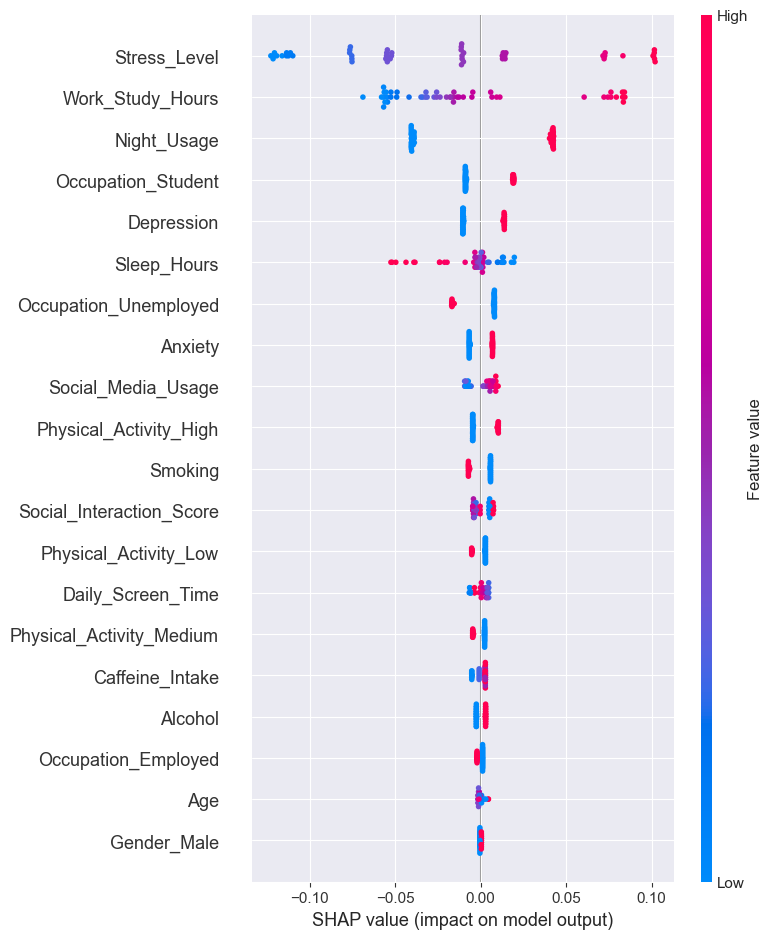

SHAP Summary Plot - Support Vector Machine


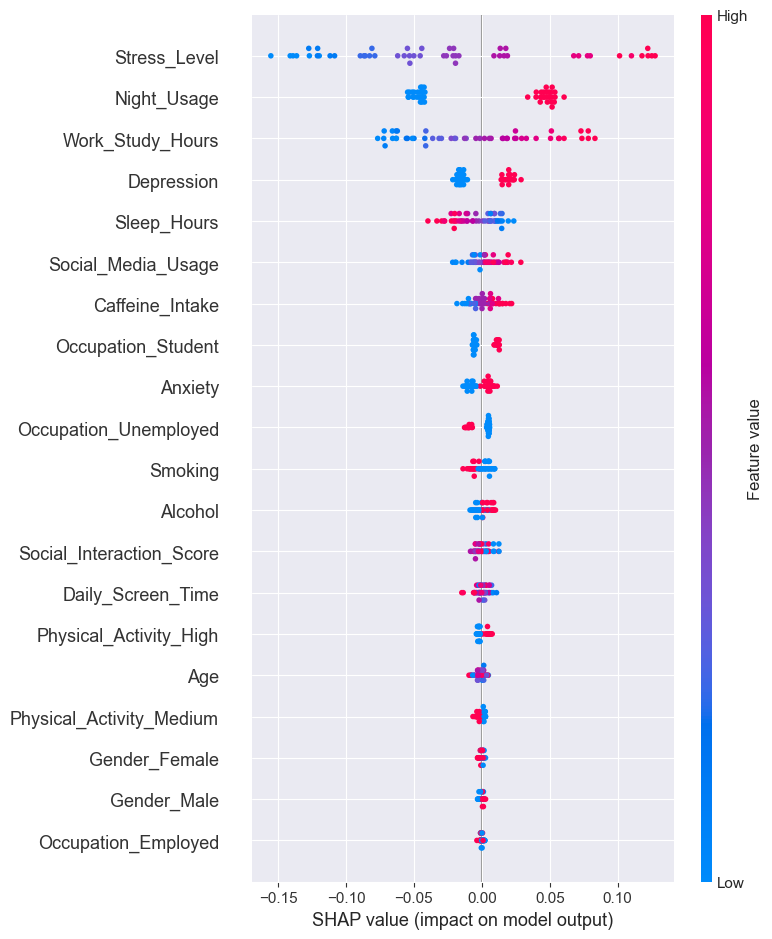

SHAP Summary Plot - Logistic Regression


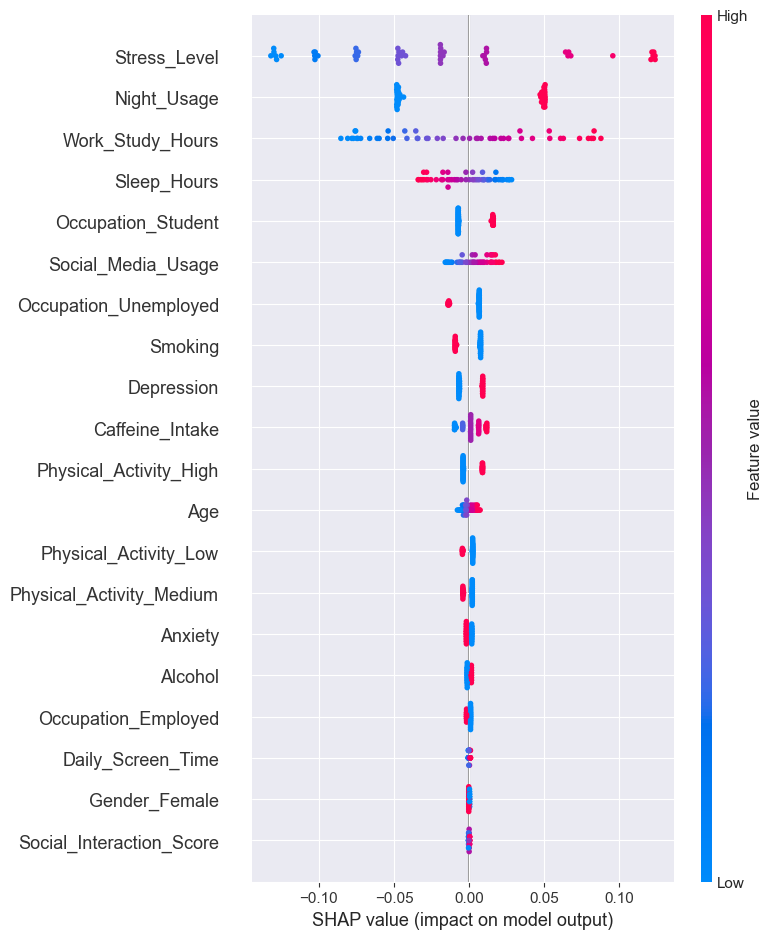

In [74]:
for model_name in top_3_tuned_model_names:
    print(f"SHAP Summary Plot - {model_name}")

    shap.summary_plot(
        shap_values_dict[model_name].values,
        shap_data_dict[model_name],
        feature_names=shap_values_dict[model_name].feature_names
    )

SHAP Bar Plot - Explainable Boosting Machine


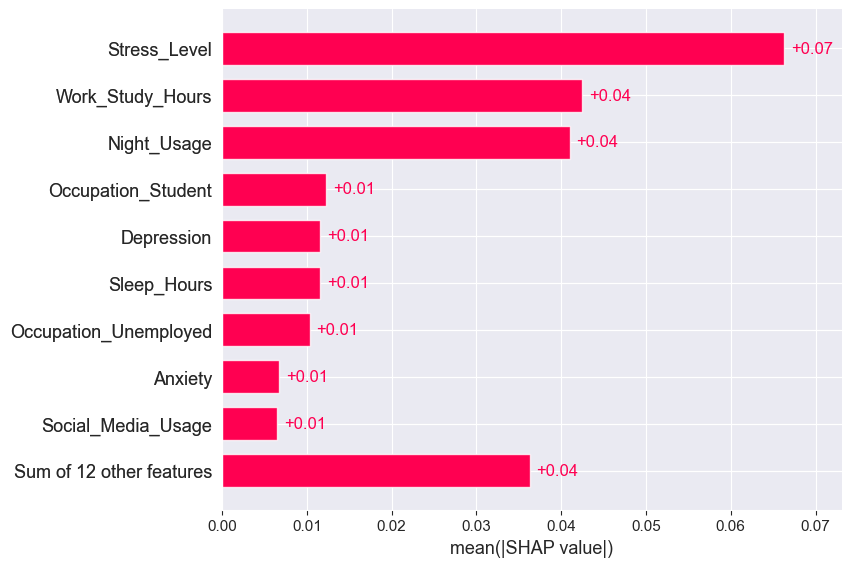

SHAP Bar Plot - Support Vector Machine


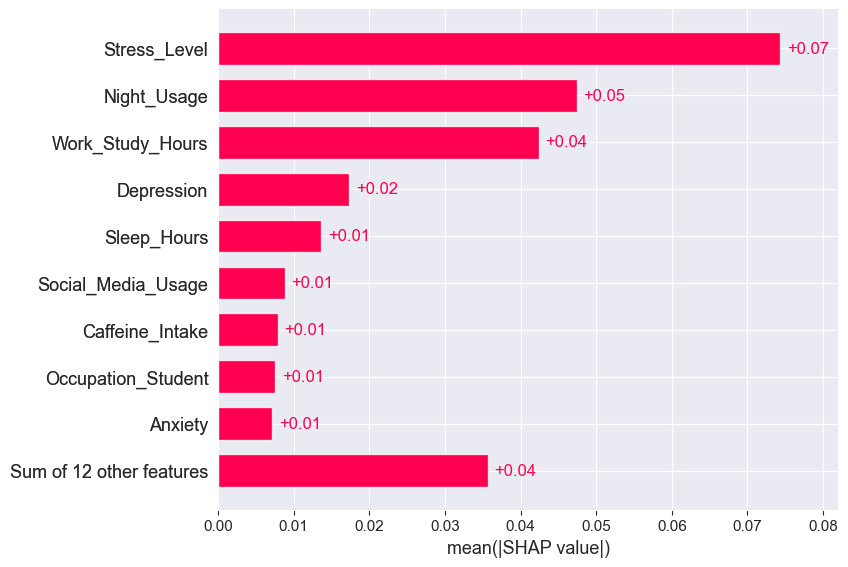

SHAP Bar Plot - Logistic Regression


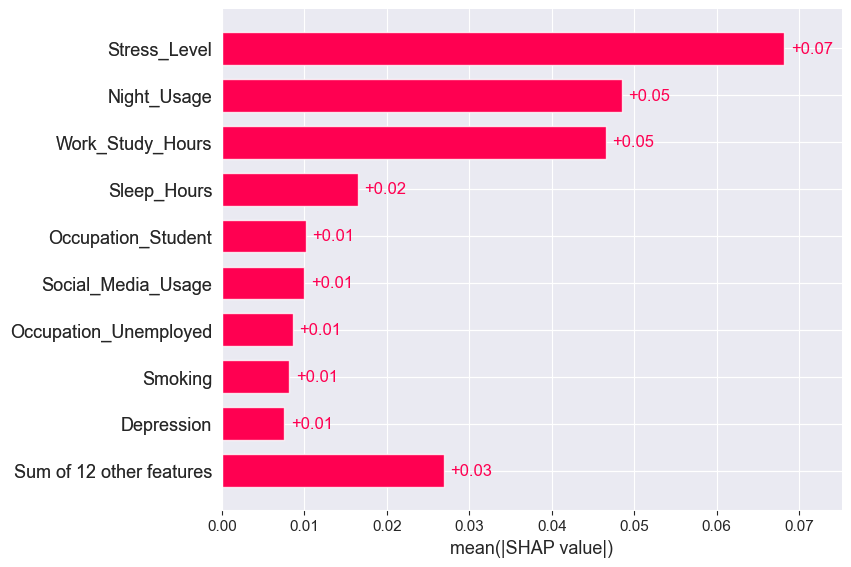

In [75]:
for model_name in top_3_tuned_model_names:
    print(f"SHAP Bar Plot - {model_name}")

    shap.plots.bar(
        shap_values_dict[model_name],
        max_display=10
    )

SHAP Waterfall Plot - Explainable Boosting Machine


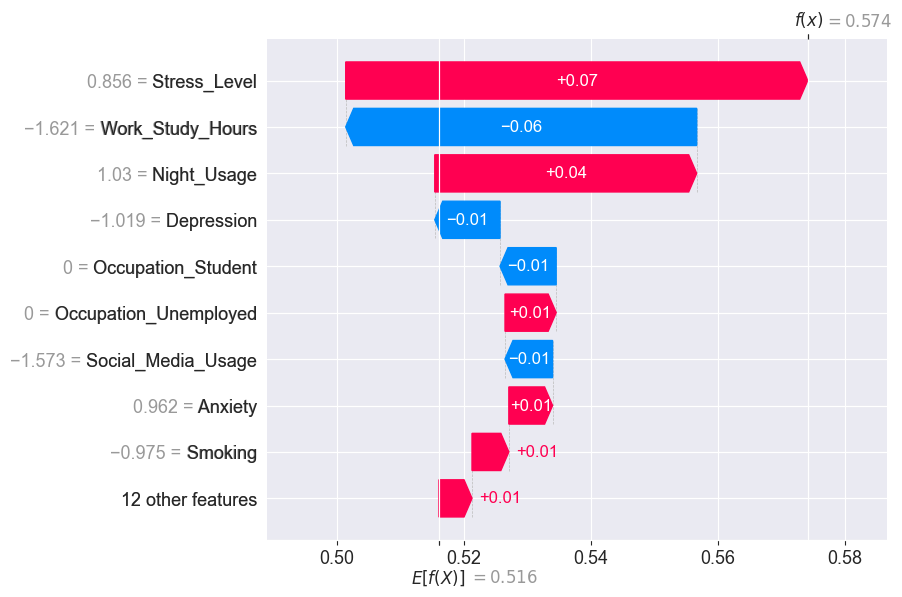

SHAP Waterfall Plot - Support Vector Machine


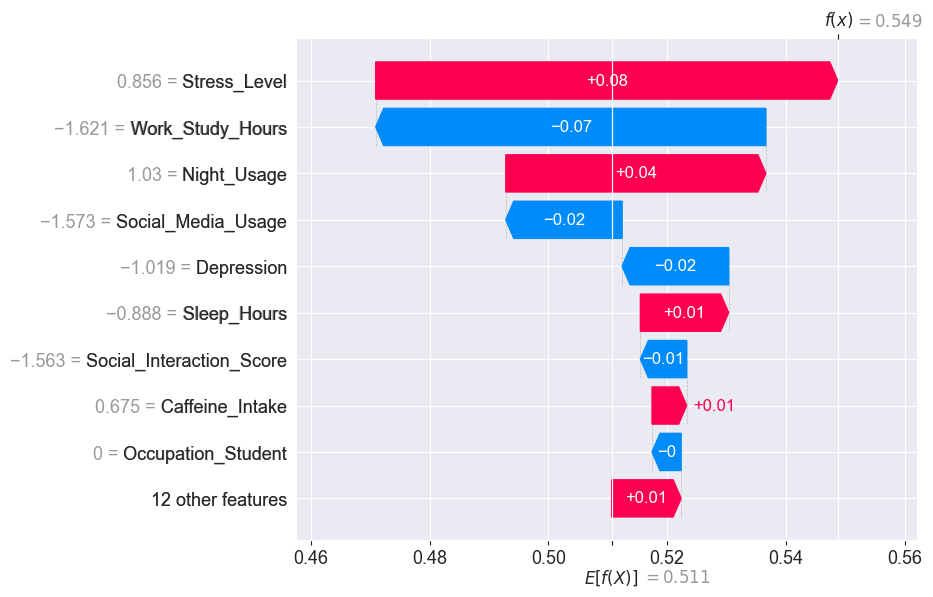

SHAP Waterfall Plot - Logistic Regression


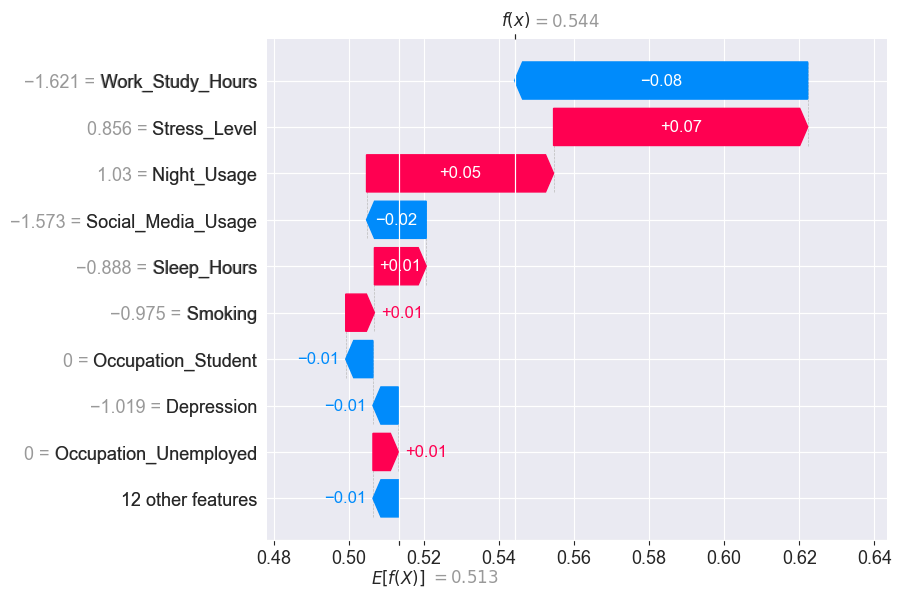

In [76]:
for model_name in top_3_tuned_model_names:
    print(f"SHAP Waterfall Plot - {model_name}")

    shap.plots.waterfall(
        shap_values_dict[model_name][0],
        max_display=10
    )

SHAP Scatter Plots - Explainable Boosting Machine
Top 3 SHAP features: ['Stress_Level', 'Work_Study_Hours', 'Night_Usage']


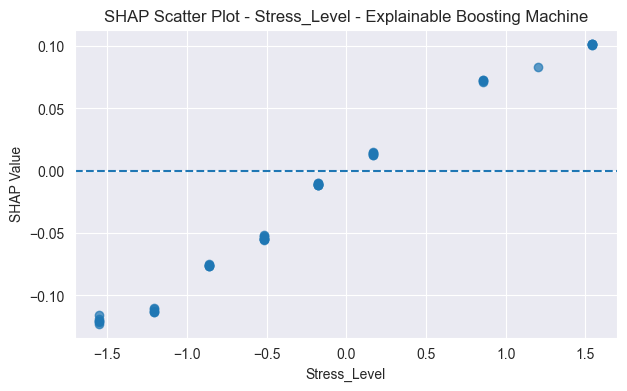

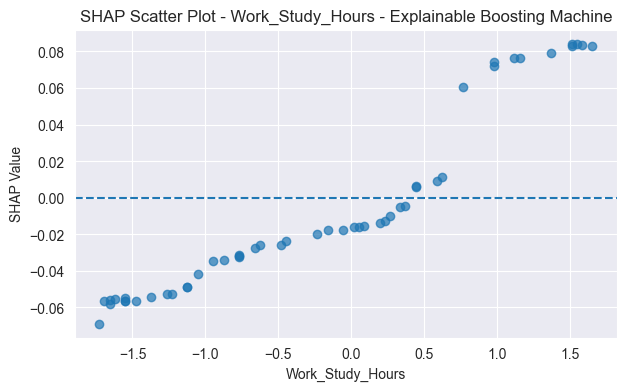

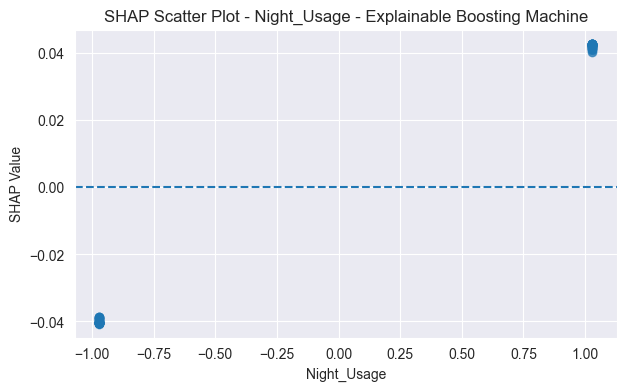

SHAP Scatter Plots - Support Vector Machine
Top 3 SHAP features: ['Stress_Level', 'Night_Usage', 'Work_Study_Hours']


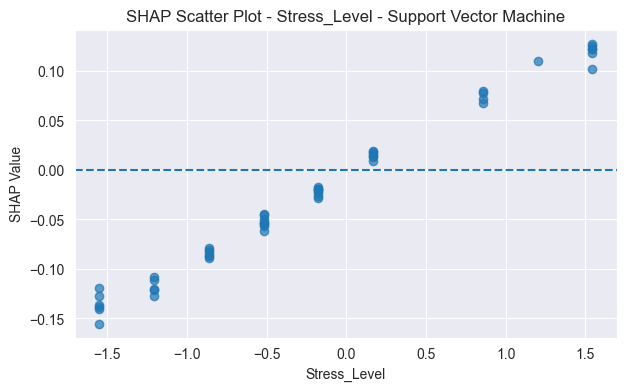

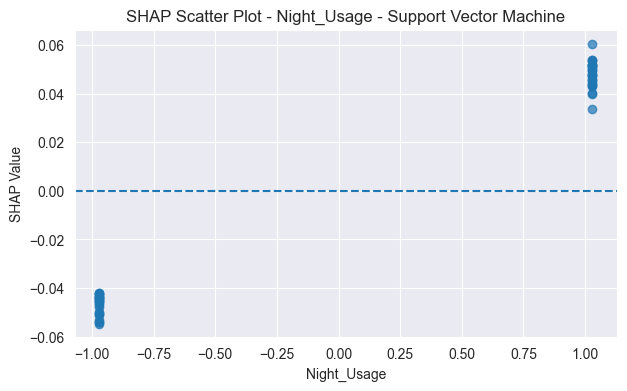

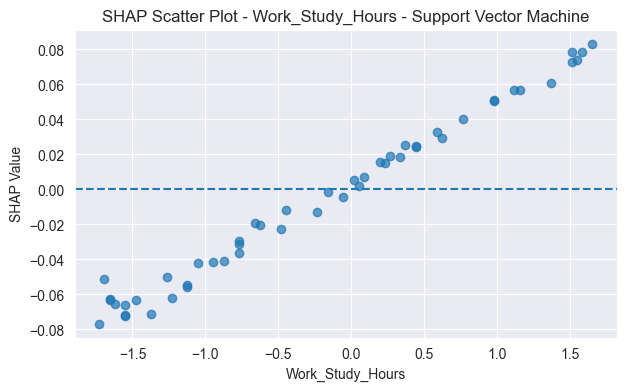

SHAP Scatter Plots - Logistic Regression
Top 3 SHAP features: ['Stress_Level', 'Night_Usage', 'Work_Study_Hours']


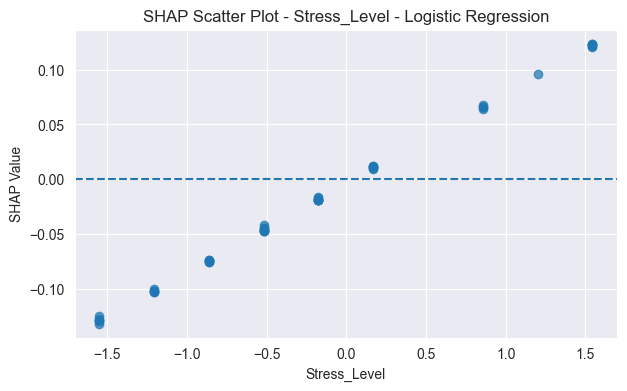

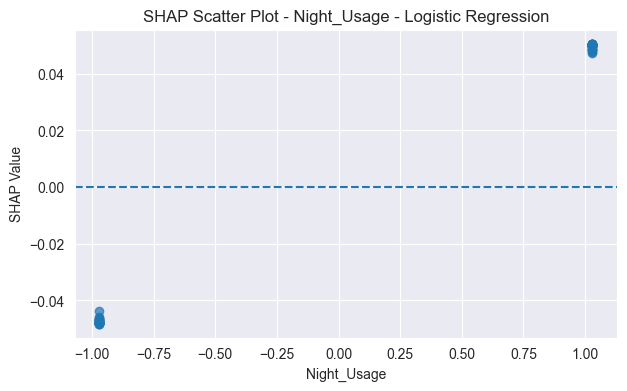

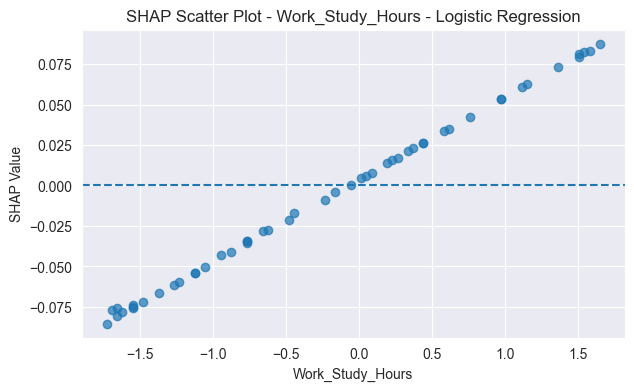

In [77]:
for model_name in top_3_tuned_model_names:
    print(f"SHAP Scatter Plots - {model_name}")

    shap_values = shap_values_dict[model_name]
    explain_data = shap_data_dict[model_name]

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    top_features = pd.Series(
        mean_abs_shap,
        index=shap_values.feature_names
    ).sort_values(ascending=False).head(3).index.tolist()

    print("Top 3 SHAP features:", top_features)

    for feature in top_features:
        feature_index = list(shap_values.feature_names).index(feature)

        plt.figure(figsize=(7, 4))
        plt.scatter(
            explain_data[feature],
            shap_values.values[:, feature_index],
            alpha=0.7
        )
        plt.axhline(0, linestyle="--")
        plt.title(f"SHAP Scatter Plot - {feature} - {model_name}")
        plt.xlabel(feature)
        plt.ylabel("SHAP Value")
        plt.show()

## SHAP Interpretation

The SHAP analysis was performed for the top three tuned classification models.

For the Explainable Boosting Machine, the most important features were `Stress_Level`, `Work_Study_Hours`, and `Night_Usage`. The SHAP scatter plots show that higher values of `Stress_Level` tend to increase the prediction toward class 1, meaning burnout. A similar pattern can be observed for `Work_Study_Hours`, where higher values tend to push the model prediction toward burnout.

For the Support Vector Machine, the most relevant features were also `Stress_Level`, `Night_Usage`, and `Work_Study_Hours`. This confirms that stress level, night usage, and work/study intensity are important predictors for burnout in this dataset.

The `Night_Usage` feature has a clear binary effect. When night usage is active, the SHAP values are positive, meaning that this feature pushes the prediction toward burnout. When night usage is inactive, the SHAP values are negative, pushing the prediction toward no burnout.

Overall, SHAP confirms that the most influential variables are related to stress, work/study load, and nighttime digital behavior. Positive SHAP values increase the probability of burnout, while negative SHAP values decrease it.

In [79]:
import joblib

CLASSIFICATION_MODEL_PATH = PROJECT_ROOT / "models" / "best_classification_model.pkl"

joblib.dump(best_tuned_model, CLASSIFICATION_MODEL_PATH)

print("Saved best classification model to:", CLASSIFICATION_MODEL_PATH)

Saved best classification model to: D:\faculta\an3\sem2\ProiectMl\models\best_classification_model.pkl
